### Import packages and load .csv files

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.metrics.pairwise import cosine_distances

CORPUS = pd.read_csv("CORPUS.csv", sep="|")
LIB = pd.read_csv("LIB.csv", sep="|")
VOCAB = pd.read_csv("VOCAB.csv", sep="|")
TFIDF_L2 = load_npz("TFIDF_L2.npz")
TFIDF_L2_doc_ids = pd.read_csv("TFIDF_L2_doc_ids.csv", sep="|")
TFIDF_L2_terms = pd.read_csv("TFIDF_L2_terms.csv", sep="|")
LDA_THETA = pd.read_csv("LDA_THETA.csv", sep="|")

### Riff 1: Matched-prompt distance plot using TF-IDF L2 + cosine distance

In [2]:
# Align doc_ids with matrix rows
doc_ids = TFIDF_L2_doc_ids.iloc[:, 0].values

TFIDF_META = pd.DataFrame({
    "row_id": range(len(doc_ids)),
    "doc_id": doc_ids
})

TFIDF_META = TFIDF_META.merge(
    LIB[["doc_id", "Question_ID", "Group", "Source"]],
    on="doc_id",
    how="left"
)

# Helper function: get cosine distance between two groups for each matched question
def matched_group_distance(meta, matrix, group_a, group_b):
    rows = []

    for qid, qdata in meta.groupby("Question_ID"):
        a = qdata[qdata["Group"] == group_a]
        b = qdata[qdata["Group"] == group_b]

        if len(a) == 0 or len(b) == 0:
            continue

        # Take first response if there are duplicates
        a_row = a.iloc[0]["row_id"]
        b_row = b.iloc[0]["row_id"]

        dist = cosine_distances(
            matrix[a_row],
            matrix[b_row]
        )[0, 0]

        rows.append({
            "Question_ID": qid,
            "Comparison": f"{group_a} vs {group_b}",
            "cosine_distance": dist
        })

    return pd.DataFrame(rows)

# Compute matched distances
DIST_HUMAN_OLD = matched_group_distance(TFIDF_META, TFIDF_L2, "Human", "Old_AI")
DIST_HUMAN_NEW = matched_group_distance(TFIDF_META, TFIDF_L2, "Human", "New_AI")
DIST_OLD_NEW = matched_group_distance(TFIDF_META, TFIDF_L2, "Old_AI", "New_AI")

DISTANCES = pd.concat(
    [DIST_HUMAN_OLD, DIST_HUMAN_NEW, DIST_OLD_NEW],
    ignore_index=True
)

# Save output
DISTANCES.to_csv("MATCHED_TFIDF_DISTANCES.csv", sep="|", index=False)

DISTANCES.head()

,Question_ID,Comparison,cosine_distance
0,6,Human vs Old_AI,0.890801
1,7,Human vs Old_AI,0.810782
2,8,Human vs Old_AI,0.637493
3,13,Human vs Old_AI,0.524588
4,15,Human vs Old_AI,0.917105


C:\Users\Linoalot\AppData\Local\Temp\ipykernel_13940\3919817575.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=comparisons)


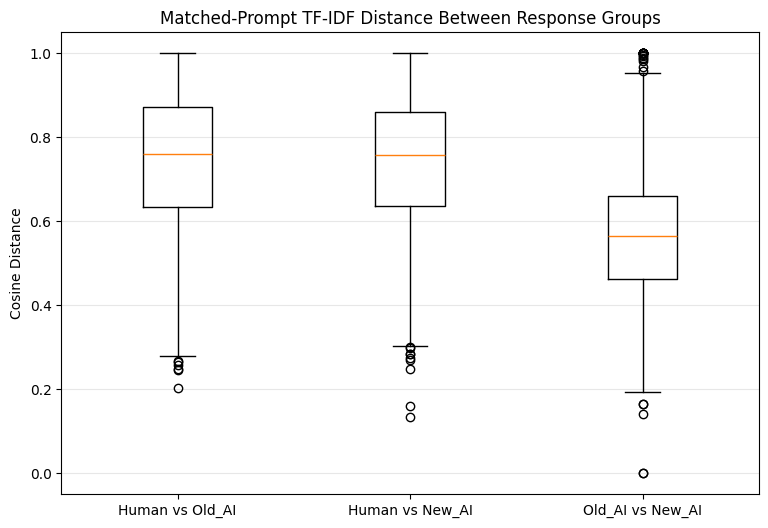

In [3]:
plt.figure(figsize=(9, 6))

comparisons = DISTANCES["Comparison"].unique()

data_to_plot = [
    DISTANCES[DISTANCES["Comparison"] == comp]["cosine_distance"]
    for comp in comparisons
]

plt.boxplot(data_to_plot, labels=comparisons)

plt.ylabel("Cosine Distance")
plt.title("Matched-Prompt TF-IDF Distance Between Response Groups")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [4]:
DISTANCES.groupby("Comparison")["cosine_distance"].agg(["mean", "median", "std", "count"])

,mean,median,std,count
Comparison,,,,
Human vs New_AI,0.741876,0.757857,0.151840,2000
Human vs Old_AI,0.741040,0.760425,0.165823,1967
Old_AI vs New_AI,0.563324,0.564793,0.147858,1967


The matched-prompt cosine distance analysis reveals that responses generated by older and newer AI models are substantially more similar to each other than to human responses. Both Human–Old_AI and Human–New_AI comparisons exhibit nearly identical mean distances (~0.74), indicating that newer AI models have not significantly reduced the lexical gap between AI and human-generated text. In contrast, the lower distance between Old_AI and New_AI (~0.56) suggests that improvements in AI models primarily refine an existing linguistic style rather than converging toward human-like language. Additionally, the greater variance observed in human comparisons indicates that human responses are more stylistically diverse, while AI-generated responses remain more consistent and standardized.

### Riff 2: LDA topic-shift heatmap by group and source

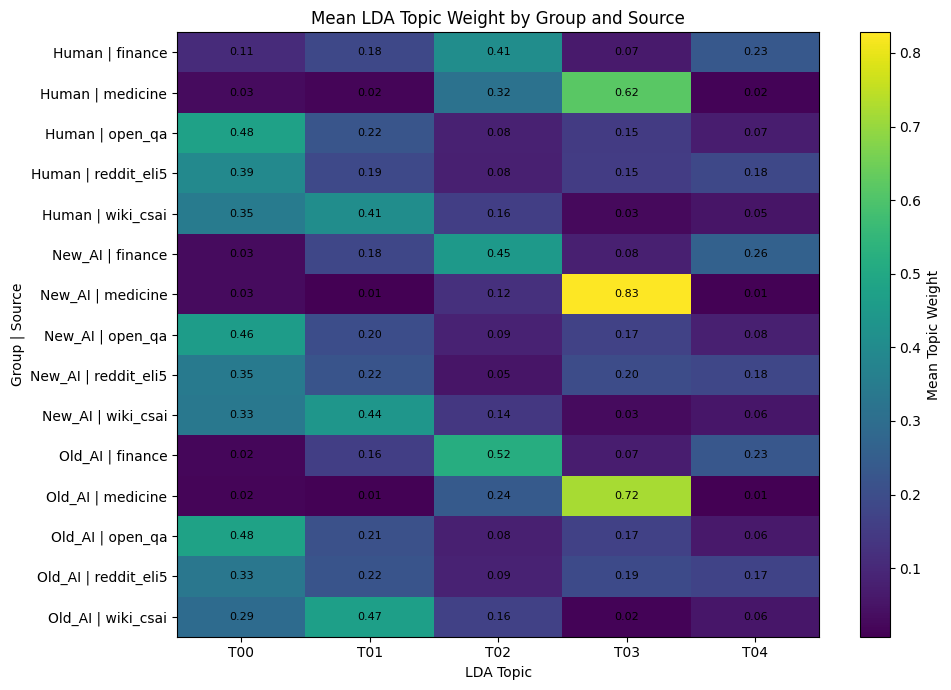

In [ ]:
# Topic columns
topic_cols = [col for col in LDA_THETA.columns if col.startswith("T")]

# Merge topic weights with metadata
THETA_META = LDA_THETA.merge(
    LIB[["doc_id", "Group", "Source"]],
    on="doc_id",
    how="left"
)

# Mean topic weights by Group and Source
TOPIC_SHIFT = (
    THETA_META
    .groupby(["Group", "Source"])[topic_cols]
    .mean()
    .reset_index()
)

# Combine Group and Source for readable heatmap rows
TOPIC_SHIFT["Group_Source"] = (
    TOPIC_SHIFT["Group"].astype(str) + " | " + TOPIC_SHIFT["Source"].astype(str)
)

HEATMAP_DATA = TOPIC_SHIFT.set_index("Group_Source")[topic_cols]

# Plot heatmap
plt.figure(figsize=(10, 7))

plt.imshow(HEATMAP_DATA, aspect="auto")

plt.colorbar(label="Mean Topic Weight")
plt.xticks(
    ticks=range(len(topic_cols)),
    labels=topic_cols
)

plt.yticks(
    ticks=range(len(HEATMAP_DATA.index)),
    labels=HEATMAP_DATA.index
)

plt.xlabel("LDA Topic")
plt.ylabel("Group | Source")
plt.title("Mean LDA Topic Weight by Group and Source")

# Add values inside cells
for i in range(HEATMAP_DATA.shape[0]):
    for j in range(HEATMAP_DATA.shape[1]):
        plt.text(
            j,
            i,
            f"{HEATMAP_DATA.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

The LDA topic heatmap reveals that topic distribution is primarily driven by the source domain of the question rather than the response generator, confirming the effectiveness of the matched-prompt design. However, consistent differences emerge between humans and AI systems: AI-generated responses exhibit greater concentration in dominant topics, particularly in structured domains such as medicine and finance, while human responses are more evenly distributed across multiple topics. This indicates that AI systems are more focused and topically concentrated, whereas human responses integrate a wider range of contextual information beyond the central theme.

### Riff 3

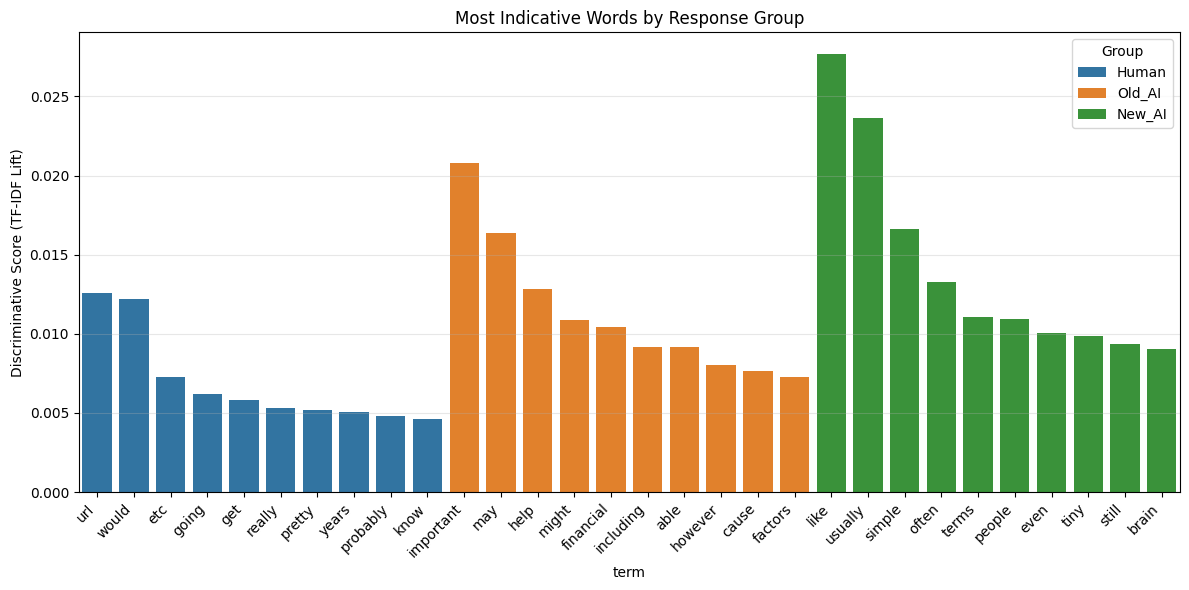

In [9]:
# Load data
terms = TFIDF_L2_terms.iloc[:, 0].astype(str).values
doc_ids = TFIDF_L2_doc_ids.iloc[:, 0].values

# Trim terms to match TF-IDF matrix width
terms = terms[:TFIDF_L2.shape[1]]

# Align metadata
META = pd.DataFrame({
    "row_id": range(len(doc_ids)),
    "doc_id": doc_ids
}).merge(
    LIB[["doc_id", "Group"]],
    on="doc_id",
    how="left"
)

# Compute mean TF-IDF per group
group_means = {}

for group in META["Group"].unique():
    rows = META[META["Group"] == group]["row_id"].values
    group_means[group] = TFIDF_L2[rows].mean(axis=0).A1

GROUP_MEANS = pd.DataFrame(group_means, index=terms)

# Compute discriminative score (lift vs others)
DISCRIM = pd.DataFrame(index=terms)

for group in GROUP_MEANS.columns:
    others = GROUP_MEANS.drop(columns=group).mean(axis=1)
    DISCRIM[group] = GROUP_MEANS[group] - others

# Get top words per group
top_n = 10
top_words = []

for group in DISCRIM.columns:
    top = DISCRIM[group].sort_values(ascending=False).head(top_n)
    df = pd.DataFrame({
        "term": top.index,
        "score": top.values,
        "Group": group
    })
    top_words.append(df)

TOP_WORDS = pd.concat(top_words, ignore_index=True)

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=TOP_WORDS,
    x="term",
    y="score",
    hue="Group"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Discriminative Score (TF-IDF Lift)")
plt.title("Most Indicative Words by Response Group")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()